# 02. MATPOWER와 pandapower baseline, 그리고 병목

초기 Python baseline은 standalone PYPOWER가 아니라 **pandapower 안에 포함된 PYPOWER-derived Newton path**로 정리되어 있습니다. benchmark ID는 과거 호환 때문에 `pypower-pandapower`로 남아 있지만, 설명할 때는 pandapower baseline으로 보는 것이 맞습니다.

이번 튜토리얼에서는 MATLAB/MATPOWER baseline도 live run에 포함합니다. 이후부터는 작은 `case9`가 아니라 약 6000-bus 규모의 `case6468rte`로 넘어갑니다.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'cuPF').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from python.tutorial import tutorial_utils as tu

plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['axes.grid'] = False

TUTORIAL_CASE = tu.TUTORIAL_LARGE_CASE
RUN_LIVE = True


In [2]:
case = tu.load_case(TUTORIAL_CASE)
print(f"case={case.case_name}, buses={case.ybus.shape[0]}, ybus_nnz={case.ybus.nnz}, pv={len(case.pv)}, pq={len(case.pq)}")
display(tu.solver_catalog())
print(tu.print_environment_note())


case=case6468rte, buses=6468, ybus_nnz=22598, pv=641, pq=5826


,Path,Jacobian,Linear solver,Benchmark ID
0,pandapower PYPOWER-derived NR,pandapower.pypower dSbus_dV sparse block assembly,scipy.sparse.linalg.spsolve; SuperLU here unle...,pypower-pandapower
1,MATPOWER default,MATPOWER makeJac/dSbus_dV NR Jacobian,MATLAB default sparse solve,matpower-default
2,MATPOWER LU5,MATPOWER makeJac/dSbus_dV NR Jacobian,MATPOWER pf.nr.lin_solver='LU5',matpower-lu5
3,cuPF CPU comparable path,Pandapower-like CPU Jacobian,SuiteSparse UMFPACK or KLU,cupf-cpu-*-pandapower-jac
4,cuPF CPU optimized path,native fixed-pattern Jacobian fill,KLU with symbolic reuse,cupf-cpu-klu
5,cuPF GPU,"CUDA Edge, EdgeAtomic, or VertexWarp",cuDSS or custom,cupf-fp64-cudss-*


pandapower.pypower.newtonpf calls scipy.sparse.linalg.spsolve; scikits.umfpack is not installed; SciPy spsolve uses SuperLU-style path here.


## Python NR stage profiling

아래 셀은 pandapower/PYPOWER 계열에서 쓰는 `dSbus_dV` 수식과 SciPy sparse solve를 직접 호출해 stage별 시간을 잽니다. 목적은 절대 성능 수치보다 **어느 단계가 병목인지**를 눈으로 보는 것입니다.


converged=True, iterations=3, final_mismatch=7.732e-12


,time_ms
stage,
Linear solve,44.392097
Jacobian,24.243465
Voltage update,0.894777
Mismatch,0.621044


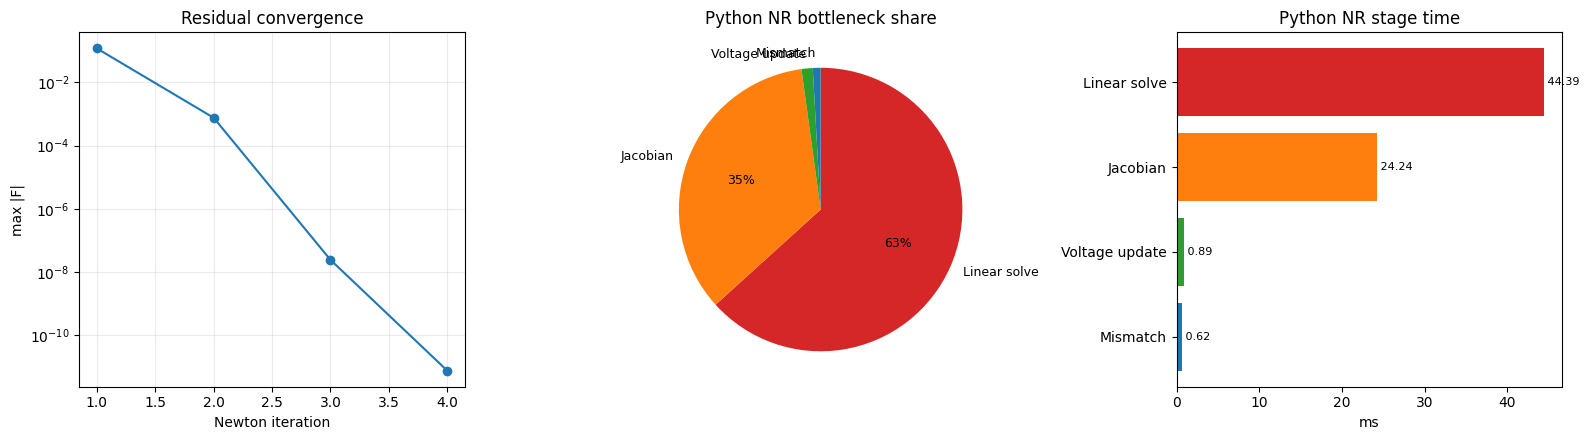

In [3]:
trace = tu.run_newton_with_stage_timing(case, tolerance=1e-8, max_iter=50)
print(f"converged={trace.converged}, iterations={trace.iterations}, final_mismatch={trace.final_mismatch:.3e}")
display(trace.stage_totals_ms.rename('time_ms').to_frame())
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
tu.plot_convergence(trace, axes[0])
tu.plot_stage_pie(trace.stage_totals_ms, axes[1], 'Python NR bottleneck share')
tu.plot_stage_bar(trace.stage_totals_ms, axes[2], 'Python NR stage time')
plt.tight_layout()


## Live baseline benchmark

이 셀은 기존 결과 CSV를 읽지 않습니다. `python.tests.run_benchmark`를 직접 실행해서 `python/tutorial/_runs` 아래에 새 결과를 만듭니다. MATLAB 로그인이나 라이선스가 실패하면 그 사유를 skip table로 남깁니다.


$ /usr/bin/python3 -m python.tests.run_benchmark --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --run-name tutorial-baseline-20260601-103847 --cases case6468rte --repeats 1 --warmup 0 --variants pypower-pandapower matpower-default matpower-lu5
[OK] elapsed=27.7s
[benchmark][RUN] /usr/bin/python3 -m python.tests.run_pypower --dataset-root /datasets/matpower --run-name tutorial-baseline-20260601-103847 --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --warmup 0 --repeats 1 --tolerance 1e-08 --max-iter 50 --reference-tolerance 1e-10 --reference-max-iter 80 --no-aggregate --cases case6468rte
[pypower-pandapower][OK] case6468rte repeat=0 init_ms=259.522 solve_ms=72.771 iters=3 resid=7.732e-12
[pypower-pandapower] wrote /workspace/gpu-powerflow-master/python/tutorial/_runs/tutorial-baseline-20260601-103847/pypower-pandapower/runs.csv
[benchmark][RUN] /usr/bin/python3 -m python.tests.run_matpower --dataset-root /datasets/matpower --run-name tutorial-bas

,variant,cases,successful_rows,converged_rows,initialize_ms,solve_ms,worst_residual,linear_solver,jacobian,entrypoint
2,pypower-pandapower,1,1,1,259.521667,72.771402,7.732085e-12,scipy-spsolve,nan,pandapower.pypower
0,matpower-default,1,1,1,387.071000,1038.290000,1.781664e-11,default,nan,matlab-runpf
1,matpower-lu5,1,1,1,385.981000,1049.331000,1.203992e-11,LU5,nan,matlab-runpf


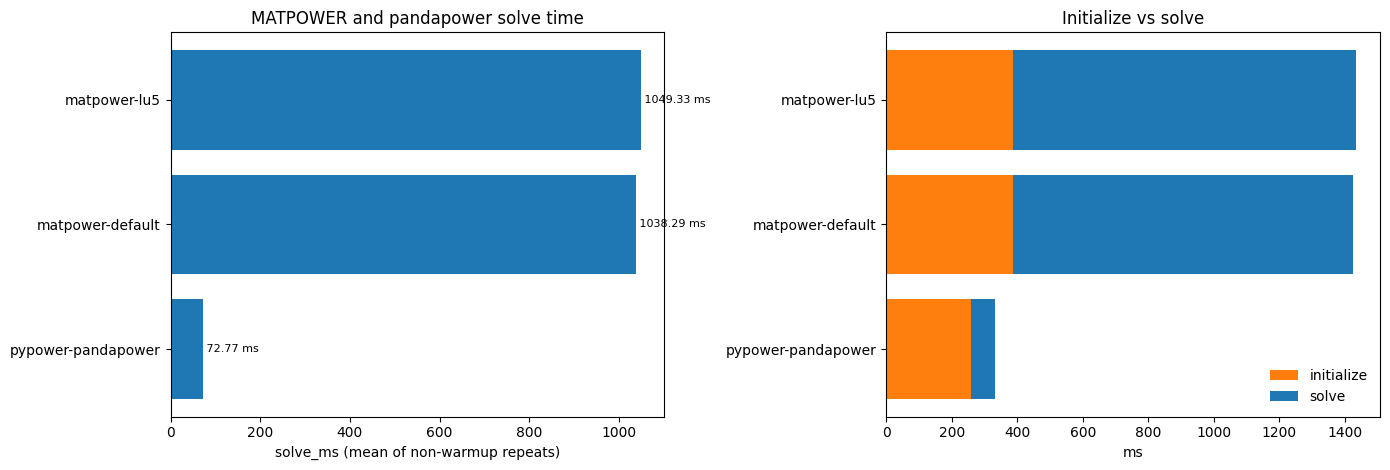

In [4]:
variants = ['pypower-pandapower', 'matpower-default', 'matpower-lu5']
if RUN_LIVE:
    run_dir, result = tu.run_tutorial_benchmark(
        variants=variants,
        run_name=tu.timestamp_run_name('tutorial-baseline'),
        cases=[TUTORIAL_CASE],
        repeats=1,
        warmup=0,
        timeout=7200,
    )
    print(tu.command_summary(result))
else:
    run_dir = tu.tutorial_output_root()

print(f"run_dir={run_dir}")
runs = tu.load_tutorial_runs(run_dir)
summary = tu.summarize_runs(runs)
display(summary)
skipped = tu.skipped_variants(run_dir)
if not skipped.empty:
    display(skipped)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
tu.plot_run_solve_bars(summary, axes[0], 'MATPOWER and pandapower solve time')
tu.plot_init_solve_stack(summary, axes[1], 'Initialize vs solve')
plt.tight_layout()


MATPOWER는 MATLAB sparse linear algebra 위에서 동작하고, `LU5`는 MATPOWER가 제공하는 sparse LU 선택지입니다. pandapower baseline은 이 환경에서 `scikits.umfpack`이 없으면 SciPy SuperLU 계열 `spsolve`로 보는 것이 맞습니다.
